In [5]:
import shutil
import os
from google.colab import drive

drive.mount('/content/drive')

base = '/content/drive/MyDrive/Aerial Object Classification & Detection'

shutil.copytree(
    os.path.join(base, 'train-20260409T091319Z-3-001', 'train'),
    '/content/dataset/train')
shutil.copytree(
    os.path.join(base, 'valid-20260409T091319Z-3-001', 'valid'),
    '/content/dataset/valid')

shutil.copytree(
    os.path.join(base, 'test-20260409T091319Z-3-001', 'test'),
    '/content/dataset/test')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/dataset/test'

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("GPU:", tf.config.list_physical_devices('GPU'))

TRAIN_DIR = '/content/dataset/train/'
VALID_DIR = '/content/dataset/valid/'
TEST_DIR  = '/content/dataset/test/'

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 20


Mounted at /content/drive
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
for split in ['train', 'valid', 'test']:
    for cls in ['bird', 'drone']:
        path = f'/content/dataset/{split}/{cls}'
        if os.path.exists(path):
            print(f"{split}/{cls}: {len(os.listdir(path))} images")
        else:
            print(f"MISSING: {split}/{cls} — Re-copy from Drive!")

MISSING: train/bird — Re-copy from Drive!
MISSING: train/drone — Re-copy from Drive!
MISSING: valid/bird — Re-copy from Drive!
MISSING: valid/drone — Re-copy from Drive!
MISSING: test/bird — Re-copy from Drive!
MISSING: test/drone — Re-copy from Drive!


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

# ✅ Use EfficientNet's own preprocessor instead of rescale=1./255
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # ✅ KEY FIX
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    shear_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input   # ✅ KEY FIX
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    VALID_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

print(f"Class Indices: {train_gen.class_indices}")

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 220 images belonging to 2 classes.
Class Indices: {'bird': 0, 'drone': 1}


Building EfficientNetB0 Model

In [7]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base
base_model.trainable = False

inputs  = tf.keras.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(128, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model_eff = models.Model(inputs, outputs)

print("✅ Model Built!")
model_eff.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Model Built!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,415,652 (16.84 MB)

 Trainable params: 363,521 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [8]:
model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

os.makedirs('/content/drive/MyDrive/Aerial Object Classification & Detection/models/', exist_ok=True)
save_path = '/content/drive/MyDrive/Aerial Object Classification & Detection/models/efficientnet_best.h5'

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(save_path, monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1)
]

In [10]:
history1 = model_eff.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)
print(f"Best Val Accuracy: {max(history1.history['val_accuracy'])*100:.2f}%")

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 681ms/step - accuracy: 0.8521 - loss: 0.3620 - precision: 0.8286 - recall: 0.8876
Epoch 1: val_accuracy improved from None to 0.97059, saving model to /content/drive/MyDrive/Aerial Object Classification & Detection/models/efficientnet_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Aerial Object Classification & Detection/models/efficientnet_best.h5
84/84 ━━━━━━━━━━━━━━━━━━━━ 112s 944ms/step - accuracy: 0.9196 - loss: 0.1961 - precision: 0.9097 - recall: 0.9199 - val_accuracy: 0.9706 - val_loss: 0.0888 - val_precision: 0.9530 - val_recall: 0.9911 - learning_rate: 0.0010
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.9745 - loss: 0.0590 - precision: 0.9688 - recall: 0.9765
Epoch 2: val_accuracy improved from 0.97059 to 0.98416, saving model to /content/drive/MyDrive/Aerial Object Classification & Detection/models/efficientnet_best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Aerial Object Classification & Detection/models/efficientnet_best.h5
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 511ms/step - accuracy: 0.9786 - loss: 0.0460 - precision: 0.9760 - recall: 0.9784 - val_accuracy: 0.9842 - val_loss: 0.0508 - val_precision: 0.9866 - val_recall: 0.9822 - learning_rate: 0.0010
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.9914 - loss: 0.0286 - precision: 0.9899 - recall: 0.9921
Epoch 3: val_accuracy did not improve from 0.98416
84/84 ━━━━━━━━━━━━━━━━━━━━ 41s 492ms/step - accuracy: 0.9846 - loss: 0.0426 - precision: 0.9824 - recall: 0.9848 - val_accuracy: 0.9683 - val_loss: 0.0717 - val_precision: 0.9689 - val_recall: 0.9689 - learning_rate: 0.0010
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.9818 - loss: 0.0459 - precision: 0.9795 - recall: 0.9823
Epoch 4: val_accuracy did not improve from 0.98416
84/84 ━━━━━━━━━━━━━━━━━━━━ 41s 490ms/step - accuracy: 0.9823 - loss: 0.0440 -

In [11]:
# Unfreeze top 30 layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Lower learning rate for fine tuning
model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')])

history2 = model_eff.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)
print(f"Best Val Accuracy: {max(history2.history['val_accuracy'])*100:.2f}%")

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.9659 - loss: 0.0877 - precision: 0.9877 - recall: 0.9409
Epoch 1: val_accuracy did not improve from 0.98416
84/84 ━━━━━━━━━━━━━━━━━━━━ 101s 809ms/step - accuracy: 0.9654 - loss: 0.0914 - precision: 0.9833 - recall: 0.9423 - val_accuracy: 0.9796 - val_loss: 0.0488 - val_precision: 0.9954 - val_recall: 0.9644 - learning_rate: 1.0000e-05
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.9748 - loss: 0.0754 - precision: 0.9779 - recall: 0.9680
Epoch 2: val_accuracy did not improve from 0.98416
84/84 ━━━━━━━━━━━━━━━━━━━━ 41s 479ms/step - accuracy: 0.9745 - loss: 0.0710 - precision: 0.9781 - recall: 0.9671 - val_accuracy: 0.9796 - val_loss: 0.0493 - val_precision: 0.9954 - val_recall: 0.9644 - learning_rate: 1.0000e-05
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.9744 - loss: 0.0651 - precision: 0.9764 - recall: 0.9681
Epoch 3: val_accuracy did not improve from 0.98416
84/84 ━━━━━━━━━━━━━━━

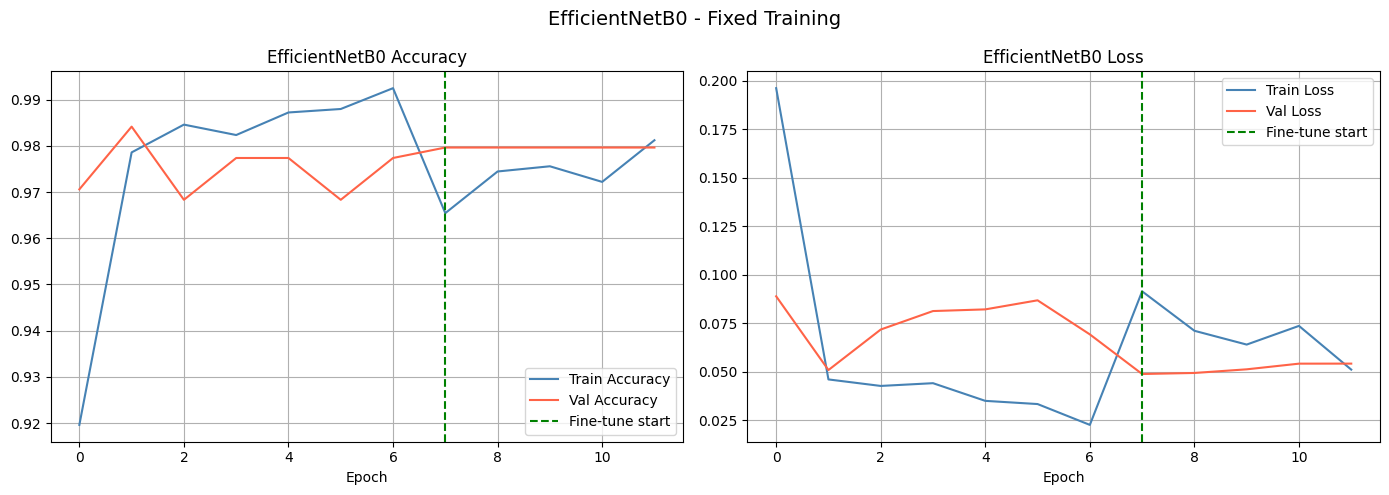

In [12]:
acc      = history1.history['accuracy']     + history2.history['accuracy']
val_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss     = history1.history['loss']         + history2.history['loss']
val_loss = history1.history['val_loss']     + history2.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(acc,     label='Train Accuracy', color='steelblue')
axes[0].plot(val_acc, label='Val Accuracy',   color='tomato')
axes[0].axvline(x=len(history1.history['accuracy']),
                color='green', linestyle='--', label='Fine-tune start')
axes[0].set_title('EfficientNetB0 Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(loss,     label='Train Loss', color='steelblue')
axes[1].plot(val_loss, label='Val Loss',   color='tomato')
axes[1].axvline(x=len(history1.history['loss']),
                color='green', linestyle='--', label='Fine-tune start')
axes[1].set_title('EfficientNetB0 Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('EfficientNetB0 - Fixed Training', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Aerial Object Classification & Detection/models/efficientnet_plot.png')
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step
              precision    recall  f1-score   support

        Bird       0.96      0.98      0.97       126
       Drone       0.98      0.95      0.96        94

    accuracy                           0.97       220
   macro avg       0.97      0.97      0.97       220
weighted avg       0.97      0.97      0.97       220



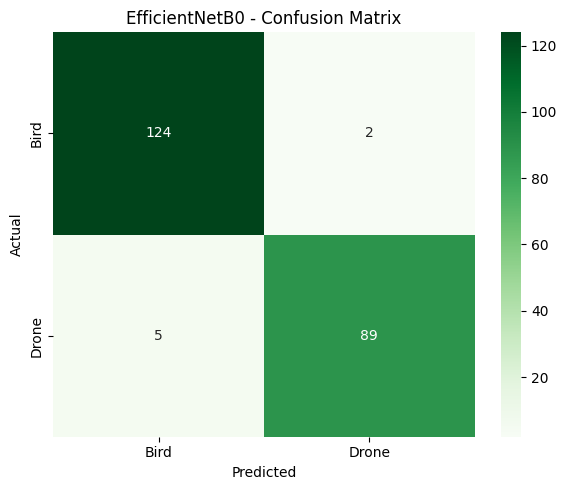

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_gen.reset()
preds       = model_eff.predict(test_gen, verbose=1)
pred_labels = (preds > 0.5).astype(int).flatten()
true_labels = test_gen.classes

print(classification_report(true_labels, pred_labels,
                            target_names=['Bird', 'Drone']))

cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Bird', 'Drone'],
            yticklabels=['Bird', 'Drone'])
plt.title('EfficientNetB0 - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Aerial Object Classification & Detection/models/efficientnet_confusion_matrix.png')
plt.show()